In [1]:
import math
import pandas as pd
import numpy as np
import warnings
from tqdm.notebook import tqdm
import wandb
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [2]:
train_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/3rd_preprocessed_data/train_multimodal_20260428_ssl.ftr")
val_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/3rd_preprocessed_data/val_multimodal_20260428_ssl.ftr")
test_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/3rd_preprocessed_data/test_multimodal_20260428_ssl.ftr")

In [3]:
# HYPERPARAMETERS
BATCH_SIZE = 128
WINDOW_SIZE = 512
PATIENCE = 5
EPOCHS = 50
MASK_PROB = 0.15
LR = 1e-4

In [4]:
class ICUTimeSeriesDataset(Dataset):
    def __init__(self, df):
        self.sequences = []
    
        exclude_cols = ['subject_id', 'hadm_id', 'stay_id', 'hour_slot']
        self.feature_cols = [col for col in df.columns if col not in exclude_cols]

        grouped = df.groupby('stay_id')

        for _, group in grouped:
            group = group.sort_values('hour_slot')

            seq_tensor = torch.tensor(group[self.feature_cols].values, dtype=torch.float32)
            self.sequences.append(seq_tensor)

        self.input_dim = len(self.feature_cols)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

def collate_fn(batch):
    batch = [seq[:WINDOW_SIZE] for seq in batch]
    lengths = torch.tensor([seq.size(0) for seq in batch])
    padded_sequences = pad_sequence(batch, batch_first=True, padding_value=0.0)
    max_len = padded_sequences.size(1)
    padding_mask = torch.arange(max_len).expand(len(lengths), max_len) >= lengths.unsqueeze(1)
    return padded_sequences, padding_mask

In [5]:
train_df

,subject_id,hadm_id,stay_id,hour_slot,220045,220045_flag,220179,220179_flag,220180,220180_flag,...,220615_flag,225668,225668_flag,bun_creatinine,bun_creatinine_flag,urine,fluid_alb,cryst_weight,225402,225794
0,10001884,26184834,37510196,0,-2.131779,1.0,2.433486,1.0,-2.150174,1.0,...,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,0.226195,0.0,0.0
1,10001884,26184834,37510196,1,-0.851027,1.0,-0.813465,1.0,-0.064900,1.0,...,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,-0.377140,0.0,0.0
2,10001884,26184834,37510196,2,-0.925273,1.0,-0.836171,1.0,0.320074,1.0,...,1.0,-0.148898,1.0,0.431466,1.0,-0.067542,0.0,-0.278976,1.0,0.0
3,10001884,26184834,37510196,3,-0.906712,1.0,-0.813465,1.0,0.448398,1.0,...,1.0,-0.148898,1.0,0.431466,1.0,1.014560,0.0,1.067636,1.0,0.0
4,10001884,26184834,37510196,4,-0.906712,1.0,0.821363,1.0,0.769210,1.0,...,1.0,-0.148898,1.0,0.431466,1.0,0.211082,0.0,-0.341659,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,19999987,23865745,36195440,42,0.596779,1.0,1.457130,1.0,1.795806,1.0,...,1.0,0.000000,0.0,-0.305491,1.0,0.000000,0.0,0.000000,0.0,0.0
1618767,19999987,23865745,36195440,43,0.596779,1.0,1.457130,1.0,1.795806,1.0,...,1.0,0.000000,0.0,-0.305491,1.0,0.000000,0.0,0.000000,0.0,0.0
1618768,19999987,23865745,36195440,44,0.318355,1.0,1.956661,1.0,3.592350,1.0,...,1.0,0.000000,0.0,-0.305491,1.0,1.787521,0.0,0.000000,0.0,0.0
1618769,19999987,23865745,36195440,45,0.262670,1.0,1.956661,1.0,3.592350,1.0,...,1.0,0.000000,0.0,-0.305491,1.0,-0.685490,0.0,0.544918,0.0,0.0


In [6]:
train_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'hour_slot', '220045',
       '220045_flag', '220179', '220179_flag', '220180', '220180_flag',
       '220210', '220210_flag', '223761', '223761_flag', 'spo2_fio2',
       'spo2_fio2_flag', '220277', '220277_flag', '223835', '223835_flag',
       '225624', '225624_flag', '220645', '220645_flag', '227073',
       '227073_flag', '227429', '227429_flag', '227442', '227442_flag',
       '227445', '227445_flag', '227446', '227446_flag', '227456',
       '227456_flag', '50963', '50963_flag', '220546', '220546_flag', '220615',
       '220615_flag', '225668', '225668_flag', 'bun_creatinine',
       'bun_creatinine_flag', 'urine', 'fluid_alb', 'cryst_weight', '225402',
       '225794'],
      dtype='object')

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

train_dataset = ICUTimeSeriesDataset(train_df)
val_dataset = ICUTimeSeriesDataset(val_df)

print(f"Model Input Dimension: {train_dataset.input_dim}")

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True
)

device: cuda
Model Input Dimension: 47


In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, window_size, num_layers=3, num_heads=8, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_size, hidden_size)
        self.ln_output = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

        self.pos_encoder = PositionalEncoding(hidden_size, dropout, max_len=window_size)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size, 
            nhead=num_heads, 
            dim_feedforward=hidden_size * 4, 
            dropout=dropout, 
            activation='gelu', 
            batch_first=True,
            norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers, enable_nested_tensor=False) # enabled_nested_tensor는 Pre-Norm 구조에서 불가피
        

    def forward(self, x, padding_mask=None):
        x_proj = self.input_projection(x) # Linear
        x_proj = self.pos_encoder(x_proj) # Positional Encoding
        output = self.transformer_encoder(x_proj, src_key_padding_mask=padding_mask)
        output = self.ln_output(output)
        return self.dropout(output)

In [9]:
class SSLMaskedTimeSeriesModel(nn.Module):
    def __init__(self, input_size, hidden_size, window_size, feature_info, mask_prob=0.15):
        super().__init__()
        self.input_size = input_size
        self.feature_info = feature_info 
        self.mask_prob = mask_prob
        self.num_maskable = len(feature_info) # 실제 복원해야 할 변수의 개수
        
        self.encoder = TransformerEncoder(input_size, hidden_size, window_size)
        
        self.learnable_mask = nn.Parameter(torch.randn(self.num_maskable))

        self.reconstruction_head = nn.Linear(hidden_size, self.num_maskable)

    def forward(self, sequences, padding_mask):
        batch_size, seq_len, _ = sequences.size()
        masked_sequences = sequences.clone()
        
        ssl_mask_matrix = torch.zeros((batch_size, seq_len, self.num_maskable), dtype=torch.bool, device=sequences.device)
        
        for i, (feat_idx, flag_idx) in enumerate(self.feature_info):
            prob = torch.full((batch_size, seq_len), self.mask_prob, device=sequences.device)
            valid_mask = ~padding_mask
            
            # 원본 데이터가 '결측'인 경우 복원 대상에서 제외
            if flag_idx is not None:
                is_measured = (sequences[:, :, flag_idx] == 1) 
                valid_mask = valid_mask & is_measured
            
            # 최종 마스킹 위치 결정 (mask_prob 확률 & 패딩 아님 & 실제 측정됨)
            ssl_mask_i = torch.bernoulli(prob).bool() & valid_mask
            ssl_mask_matrix[:, :, i] = ssl_mask_i
            
            masked_sequences[:, :, feat_idx][ssl_mask_i] = self.learnable_mask[i]

        encoded_output = self.encoder(masked_sequences, padding_mask)
        
        reconstructed = self.reconstruction_head(encoded_output)
        
        return reconstructed, ssl_mask_matrix

In [10]:
columns = train_dataset.feature_cols 
feature_info = []

exclude_from_reconstruction = ['urine', 'fluid_alb', 'cryst_weight', '225402', '225794']

for i, col in enumerate(columns):
    if col.endswith('_flag') or col in exclude_from_reconstruction:
        continue
        
    flag_col_name = f"{col}_flag"
    
    if flag_col_name in columns:
        # 짝이 되는 플래그 컬럼이 존재하는 경우 ('220045', '220045_flag', etc.)
        flag_idx = columns.index(flag_col_name)
        feature_info.append((i, flag_idx))
    else:
        # 플래그 컬럼이 없는 변수들 ('urine', 'fluid_alb', etc.)
        feature_info.append((i, None))

print(feature_info) 

model = SSLMaskedTimeSeriesModel(
    input_size=train_dataset.input_dim, 
    hidden_size=512, 
    window_size=WINDOW_SIZE, 
    feature_info=feature_info,
    mask_prob=MASK_PROB
).to(device)

[(0, 1), (2, 3), (4, 5), (6, 7), (8, 9), (10, 11), (12, 13), (14, 15), (16, 17), (18, 19), (20, 21), (22, 23), (24, 25), (26, 27), (28, 29), (30, 31), (32, 33), (34, 35), (36, 37), (38, 39), (40, 41)]


In [11]:
wandb.init(
    project="patient-time-series",
    name="IO_Reconstruction_exclude/mask_prob=0.15",
    config={
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "window_size": WINDOW_SIZE,
        "mask_prob": MASK_PROB
    }
)

wandb: Currently logged in as: ms_jeong (ms_jeong-korea-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [12]:
feat_indices = [feat_idx for feat_idx, _ in feature_info]
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_loss = float('inf')
patience_counter = 0

for epoch in tqdm(range(EPOCHS), total=EPOCHS, desc="Patient Time-series Reconstruction", leave=True, dynamic_ncols=True):
    # Train
    model.train()
    total_loss, num_batches = 0.0, 0

    for padded_sequences, padding_mask in train_loader:
        features = padded_sequences.to(device)
        padding_mask = padding_mask.to(device)

        optimizer.zero_grad()
        reconstructed, ssl_mask = model(features, padding_mask)

        if ssl_mask.sum() > 0:
            original_maskable = features[:, :, feat_indices]
            loss = F.mse_loss(reconstructed[ssl_mask], original_maskable[ssl_mask])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

    avg_train_loss = total_loss / num_batches

    # Validation
    model.eval()
    val_loss, val_batches = 0.0, 0

    with torch.no_grad():
        for padded_sequences, padding_mask in val_loader:
            features = padded_sequences.to(device)
            padding_mask = padding_mask.to(device)

            reconstructed, ssl_mask = model(features, padding_mask)

            if ssl_mask.sum() > 0:
                original_maskable = features[:, :, feat_indices]
                loss = F.mse_loss(reconstructed[ssl_mask], original_maskable[ssl_mask])
                val_loss += loss.item()
                val_batches += 1

    avg_val_loss = val_loss / val_batches if val_batches > 0 else float('nan')
    current_lr = scheduler.get_last_lr()[0]

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6e}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "learning_rate": current_lr
    })

    scheduler.step()

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_ssl_model_mask_prob=0.15_noIOcols.pt")
        
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.4f})")
            break

wandb.run.summary["best_val_loss"] = best_val_loss
wandb.run.summary["best_epoch"] = epoch + 1
wandb.finish()

Patient Time-series Reconstruction:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [1/50] Train Loss: 0.5679 | Val Loss: 0.3067 | LR: 1.000000e-04
Epoch [2/50] Train Loss: 0.3246 | Val Loss: 0.2293 | LR: 9.990232e-05
Epoch [3/50] Train Loss: 0.2708 | Val Loss: 0.1995 | LR: 9.960968e-05
Epoch [4/50] Train Loss: 0.2404 | Val Loss: 0.1742 | LR: 9.912322e-05
Epoch [5/50] Train Loss: 0.2212 | Val Loss: 0.1819 | LR: 9.844487e-05
Epoch [6/50] Train Loss: 0.2053 | Val Loss: 0.1649 | LR: 9.757730e-05
Epoch [7/50] Train Loss: 0.1960 | Val Loss: 0.1600 | LR: 9.652394e-05
Epoch [8/50] Train Loss: 0.1861 | Val Loss: 0.1666 | LR: 9.528894e-05
Epoch [9/50] Train Loss: 0.1808 | Val Loss: 0.1508 | LR: 9.387718e-05
Epoch [10/50] Train Loss: 0.1782 | Val Loss: 0.1531 | LR: 9.229423e-05
Epoch [11/50] Train Loss: 0.1723 | Val Loss: 0.1477 | LR: 9.054634e-05
Epoch [12/50] Train Loss: 0.1713 | Val Loss: 0.1449 | LR: 8.864041e-05
Epoch [13/50] Train Loss: 0.1676 | Val Loss: 0.1422 | LR: 8.658395e-05
Epoch [14/50] Train Loss: 0.1630 | Val Loss: 0.1481 | LR: 8.438508e-05
Epoch [15/50] T

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,███████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▁▁
train_loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▃▃▂▂▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,30
best_val_loss,0.12774
epoch,30
learning_rate,4e-05
train_loss,0.14547
val_loss,0.12974


---

In [13]:
def visualize_reconstruction(model, val_loader, feat_indices, feature_abbrevs, device, target_abbrev, num_samples=5):
    if target_abbrev not in feature_abbrevs:
        raise ValueError(f"'{target_abbrev}' 변수를 찾을 수 없습니다. 가능한 목록: {feature_abbrevs}")

    target_feat_idx = feature_abbrevs.index(target_abbrev)

    model.eval()
    samples_plotted = 0
    
    with torch.no_grad():
        for padded_sequences, padding_mask in val_loader:
            features = padded_sequences.to(device)
            padding_mask = padding_mask.to(device)
            
            reconstructed, ssl_mask = model(features, padding_mask)
            batch_size = features.size(0)
            
            for b in range(batch_size):
                if ssl_mask[b, :, target_feat_idx].sum() > 0:
                    
                    seq_len = (~padding_mask[b]).sum().item()
                    time_steps = np.arange(seq_len)
                    
                    original_vals = features[b, :seq_len, feat_indices[target_feat_idx]].cpu().numpy()
                    mask_positions = ssl_mask[b, :seq_len, target_feat_idx].cpu().numpy()
                    reconstructed_vals = reconstructed[b, :seq_len, target_feat_idx].cpu().numpy()
                    
                    plt.figure(figsize=(12, 4))
                    
                    # Trend
                    plt.plot(time_steps, original_vals, label='Original Trend', color='lightgray', linestyle='-', zorder=1)
                    
                    # Observed values
                    plt.scatter(time_steps[~mask_positions], original_vals[~mask_positions], 
                                color='blue', label='Observed Values', s=20, zorder=2)
                    
                    # Reconstructed
                    plt.scatter(time_steps[mask_positions], reconstructed_vals[mask_positions], 
                                color='red', marker='x', label='Reconstructed (Predicted)', s=60, zorder=3)
                    
                    # Ground Truth
                    plt.scatter(time_steps[mask_positions], original_vals[mask_positions], 
                                color='green', marker='o', facecolors='none', label='Ground Truth (Masked)', s=80, zorder=4)
                    
                    plt.title(f"Reconstruction Visualization: {target_abbrev}")
                    plt.xlabel("Time Steps (hours)")
                    plt.ylabel("Value (Normalized)")
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    plt.show()
                    
                    samples_plotted += 1
                    if samples_plotted >= num_samples:
                        return

In [26]:
MASK_PROB = 0.15

columns = val_dataset.feature_cols
feature_info = []

exclude_from_reconstruction = ['urine', 'fluid_alb', 'cryst_weight', '225402', '225794']

for i, col in enumerate(columns):
    if col.endswith('_flag') or col in exclude_from_reconstruction:
        continue
        
    flag_col_name = f"{col}_flag"
    
    if flag_col_name in columns:
        flag_idx = columns.index(flag_col_name)
        feature_info.append((i, flag_idx))
    else:
        feature_info.append((i, None))

model = SSLMaskedTimeSeriesModel(
    input_size=val_dataset.input_dim, 
    hidden_size=512, 
    window_size=WINDOW_SIZE, 
    feature_info=feature_info,
    mask_prob=MASK_PROB
).to(device)

save_path = f"best_ssl_model_mask_prob=0.15_noIOcols.pt"
checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint)
model.eval()

SSLMaskedTimeSeriesModel(
  (encoder): TransformerEncoder(
    (input_projection): Linear(in_features=47, out_features=512, bias=True)
    (ln_output): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.

In [15]:
itemid_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/icu/parquet/d_items.parquet")

feature_cols = [
    '50963', '220045', '220179',
    '220180', '220210', '220277', '220546', '220615', '220645', '223761',
    '223835', '225624', '225668', '227073', '227429', '227442', '227445',
    '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
    '221749', '221794', '221906', '221986', '222051', '222056', '225168',
    '225974', '225402', '225794'
]

# 파생변수나 fluid, urine은 안 보임.
itemid_df['itemid'] = itemid_df['itemid'].astype(str)
df = itemid_df[itemid_df['itemid'].isin(feature_cols)].reset_index(drop=True)

df['itemid'] = df['itemid'].astype(str)
id_to_abbrev = dict(zip(df['itemid'], df['abbreviation']))

In [16]:
feat_indices = [feat_idx for feat_idx, _ in feature_info]
feature_abbrevs = []

for idx in feat_indices:
    raw_col_name = val_dataset.feature_cols[idx]
    
    abbrev = id_to_abbrev.get(raw_col_name, raw_col_name) 
    feature_abbrevs.append(abbrev)

print("시각화 가능한 변수(Abbreviate) 목록:")
print(feature_abbrevs)

시각화 가능한 변수(Abbreviate) 목록:
['HR', 'NBPs', 'NBPd', 'RR', 'Temperature F', 'spo2_fio2', 'SpO2', 'FiO2', 'BUN', 'Sodium (serum)', 'Anion gap', 'Troponin-T', 'Potassium (serum)', 'CK-MB', 'Brain Natiuretic Peptide (BNP)', 'Albumin', '50963', 'WBC', 'Creatinine (serum)', 'Lactic Acid', 'bun_creatinine']


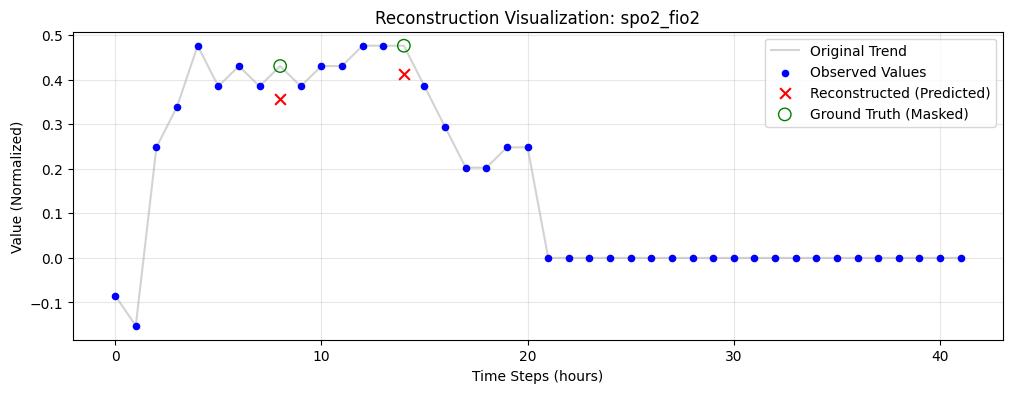

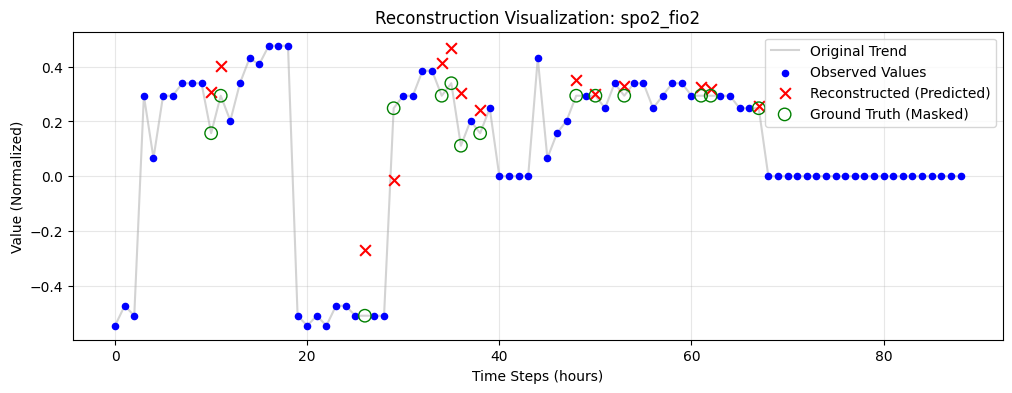

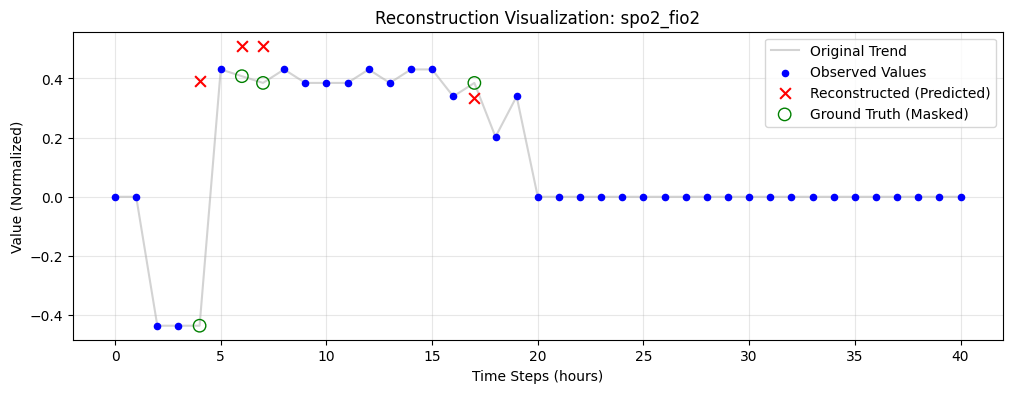

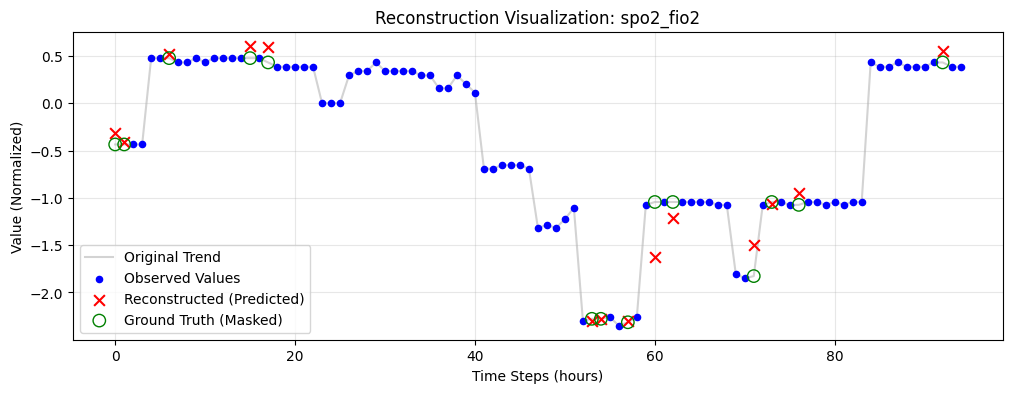

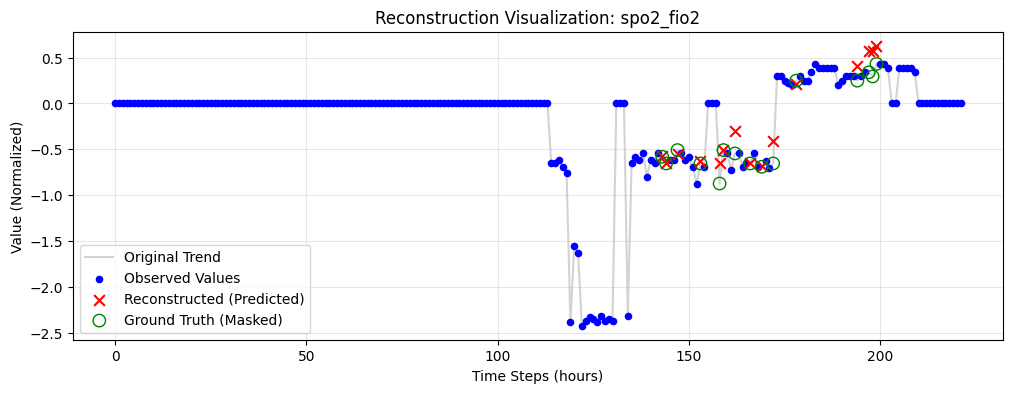

In [17]:
visualize_reconstruction(
    model=model,
    val_loader=val_loader,
    feat_indices=feat_indices,
    feature_abbrevs=feature_abbrevs,
    device=device,
    target_abbrev='spo2_fio2',
    num_samples=5
)

In [18]:
def analyze_per_feature_loss(model, dataloader, feat_indices, feature_abbrevs, device):
    model.eval()
    
    num_maskable = len(feat_indices)
    
    total_feature_loss = torch.zeros(num_maskable, device=device)
    total_feature_count = torch.zeros(num_maskable, device=device)
    
    with torch.no_grad():
        for padded_sequences, padding_mask in dataloader:
            features = padded_sequences.to(device)
            padding_mask = padding_mask.to(device)
            
            reconstructed, ssl_mask = model(features, padding_mask)
            
            original_maskable = features[:, :, feat_indices]
            
            mse_matrix = F.mse_loss(reconstructed, original_maskable, reduction='none')
            
            # 마스킹된 부분만 남기고 나머지는 0으로 만듦
            masked_mse = mse_matrix * ssl_mask.float()
            
            total_feature_loss += masked_mse.sum(dim=(0, 1))
            total_feature_count += ssl_mask.sum(dim=(0, 1))

    # 변수별 평균 MSE 계산
    valid_counts = torch.clamp(total_feature_count, min=1.0)
    per_feature_mse = (total_feature_loss / valid_counts).cpu().numpy()
    
    loss_df = pd.DataFrame({
        'Feature': feature_abbrevs,
        'MSE_Loss': per_feature_mse,
        'Masked_Count': total_feature_count.cpu().numpy() # 마스킹된 횟수도 함께 확인
    }).sort_values(by='MSE_Loss', ascending=False).reset_index(drop=True)
    
    return loss_df

def plot_per_feature_loss(loss_df):
    plt.figure(figsize=(14, 8))
    
    bars = plt.barh(loss_df['Feature'], loss_df['MSE_Loss'], color='skyblue', edgecolor='black')
    
    plt.gca().invert_yaxis()
    
    plt.title('Reconstruction MSE Loss per Feature', fontsize=16)
    plt.xlabel('MSE Loss', fontsize=14)
    plt.ylabel('Clinical Feature', fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, f'{width:.3f}', ha='left', va='center', fontsize=10)
        
    plt.tight_layout()
    plt.show()

             Feature  MSE_Loss  Masked_Count
0                 RR  0.418327       22998.0
1               NBPd  0.367547       16027.0
2               SpO2  0.324900       23005.0
3               NBPs  0.257399       16238.0
4      Temperature F  0.171744       21783.0
5                 HR  0.151044       23105.0
6  Potassium (serum)  0.094429       22681.0
7          spo2_fio2  0.057899       12148.0
8        Lactic Acid  0.054309       10159.0
9               FiO2  0.050940       12369.0


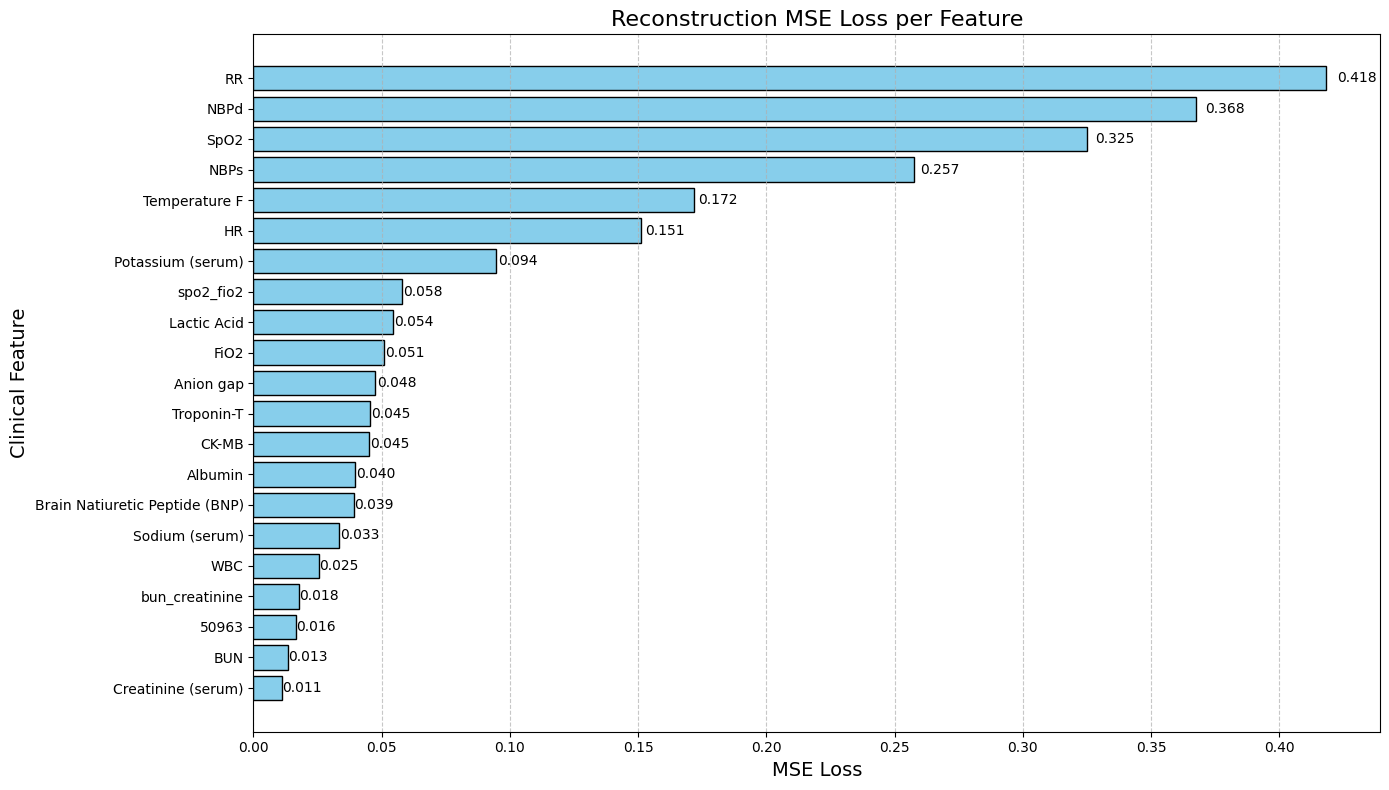

In [19]:
feature_loss_df = analyze_per_feature_loss(
    model=model,
    dataloader=val_loader,
    feat_indices=feat_indices,
    feature_abbrevs=feature_abbrevs, 
    device=device
)

print(feature_loss_df.head(10))

plot_per_feature_loss(feature_loss_df)

In [27]:
ssl_state_dict = model.encoder.state_dict()

In [ ]:
print("--- [SSL 모델 내부의 모든 Key 목록] ---")
all_keys = list(ssl_state_dict.keys())
for i, key in enumerate(all_keys[:15]):
    print(f"{i+1}. {key}")

encoder_keys = [k for k in all_keys if 'encoder' in k]
print(f"\n--- ['encoder'가 포함된 Key 개수: {len(encoder_keys)}개] ---")
if encoder_keys:
    print(f"첫 번째 예시: {encoder_keys[0]}")

--- [SSL 모델 내부의 모든 Key 목록] ---
1. input_projection.weight
2. input_projection.bias
3. ln_output.weight
4. ln_output.bias
5. pos_encoder.pe
6. transformer_encoder.layers.0.self_attn.in_proj_weight
7. transformer_encoder.layers.0.self_attn.in_proj_bias
8. transformer_encoder.layers.0.self_attn.out_proj.weight
9. transformer_encoder.layers.0.self_attn.out_proj.bias
10. transformer_encoder.layers.0.linear1.weight
11. transformer_encoder.layers.0.linear1.bias
12. transformer_encoder.layers.0.linear2.weight
13. transformer_encoder.layers.0.linear2.bias
14. transformer_encoder.layers.0.norm1.weight
15. transformer_encoder.layers.0.norm1.bias

--- ['encoder'가 포함된 Key 개수: 37개] ---
첫 번째 예시: pos_encoder.pe
